<a href="https://colab.research.google.com/github/vahagngrigoryan2006/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vahagngrigoryan2006/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**What one row means.** One content item, scored at the decision moment **2026-06-01**, using only
data observable by then (May and earlier). The label it is later checked against is whether that
item's impressions declined more than 20% in **June 2026** versus May — an outcome that had not
happened yet at the decision moment.

**Why the rule orders the queue.** Across 10 client-grouped folds on the April→May frame, I
observed the frozen rule has mean and weighted mean precision@50 noticeably higher than the models (see the code's output). At the
review budget, the rule ordered the head of the queue at least as well as either model in this
data. That is an **observed** ranking difference on one frame, not evidence that the rule is
generally superior: `w06_validation_audit.ipynb` measured the three methods' *precision* as
statistically indistinguishable (95% CI on every pairwise difference includes zero), and the models
clearly beat the rule on **recall** (tree 0.766 vs rule 0.111) and therefore F1. The rule wins where
this playbook happens to operate — the top of a short list — and loses badly on total coverage.

**Why the models still appear on every row.** They carry different information than the ordering
does. The tree's classification and its decision path say *which combination of signals* put an item
where it is; the logistic regression's probability gives a graded second opinion. Where they
disagree with the rule, that disagreement is itself the useful signal — see `QUIET_RISK_MODEL_ONLY`
below.

**Reason codes on every row:**

| Column | Values | What it tells the reviewer |
|---|---|---|
| `rule_reason` | `CTR_BELOW_POSITION_PEERS` / `NO_RULE_FLAG` | The frozen rule fired: eligible, and zero clicks against a non-zero peer benchmark. |
| `lr_reason` | `LR_HIGH_RISK` / `LR_MODERATE` / `LR_LOW_RISK` | Banded logistic-regression probability (exact value in `lr_decline_probability`). |
| `tree_reason` | `TREE_FLAGS_DECLINE` / `TREE_NO_DECLINE` | The shallow tree's own call. |
| `tree_path` | e.g. `prev_30_ctr<=0.002 AND prev_30_impressions>386` | The ≤3 conditions that produced that call — the tree's actual reasoning, in full. |
| `agreement` | `RULE_AND_MODEL_AGREE` / `RULE_ONLY` / `QUIET_RISK_MODEL_ONLY` / `NO_FLAG` | Where rule and models diverge. |

**`QUIET_RISK_MODEL_ONLY` deserves its own line.** These are items a model flags but the rule does
not — usually because the rule's eligibility gates or its strict `ctr == 0` condition exclude them.
The model offers no reason a human can read beyond `tree_path`, so these are routed to human
judgement rather than straight onto the review list. The rule supplies the rhythm; the models
supply a second opinion; neither authorises an edit.

**The eligibility gates carried over unchanged from `w04_baseline_score.ipynb`:**
`prev_30_impressions >= 500` (enough traffic to judge a CTR), `content_age_days_at_decision >= 90`
(not brand-new), `days_since_last_update_at_decision >= 60` (not just optimised).

**One tier-mean caveat, carried from `w04`:** `expected_ctr_for_tier` is pooled across clients
within each position tier. `w06_validation_audit.ipynb` raised exactly this concern about the
research paper's own Finding #3 — a pooled ratio can be dominated by whichever client has the most
traffic in that tier. The same limitation applies here and is repeated in Section 2.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

import os, json
import numpy as np
import pandas as pd
import duckdb
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

REPO_URL = "https://github.com/vahagngrigoryan2006/flyrank-internship-ml"
REPO_DIR = "flyrank-internship-ml"
import subprocess
if not os.path.isdir(REPO_DIR) and os.path.basename(os.getcwd()) != REPO_DIR:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
if os.path.basename(os.getcwd()) != REPO_DIR:
    os.chdir(REPO_DIR)

from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")
assert HF_TOKEN, "Set HF_TOKEN as a Colab secret before continuing."

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
DIM_CONTENT = f"read_parquet('{WAREHOUSE}/dim_content.parquet')"

# Read months 03-06 ONCE into a local table, then build both frames against it.
# The flyrank-data skill warns that repeated full scans hit HTTP 429 -- this is the single remote read.
MONTHS = ["2026-03", "2026-04", "2026-05", "2026-06"]
FACT_PARTS = ", ".join([f"'{WAREHOUSE}/fact_content_daily_performance/month={m}/*.parquet'" for m in MONTHS])
con.execute(f"CREATE OR REPLACE TABLE fact_4mo AS SELECT * FROM read_parquet([{FACT_PARTS}])")
print("fact_4mo rows:", con.sql("SELECT COUNT(*) FROM fact_4mo").fetchone()[0])
print("date span:", con.sql("SELECT MIN(report_date), MAX(report_date) FROM fact_4mo").fetchone())


def build_frame(as_of_date, decision_moment):
    """Same query shape as w05_model.ipynb, parameterised by as_of date.

    as_of 2026-05-31 -> prev_30 = April,      last_30 = May   (TRAINING frame)
    as_of 2026-07-01 -> prev_30 = May 2-31,   last_30 = June  (SEALED JUNE frame)
    """
    features = con.sql(f"""
        WITH bounds AS (SELECT DATE '{as_of_date}' AS as_of_date),
        per_item AS (
            SELECT f.client_hash_id, f.content_hash_id,
                   MIN(f.report_date) AS first_seen,
                   SUM(CASE WHEN f.report_date >= b.as_of_date - INTERVAL 30 DAY AND f.report_date <= b.as_of_date
                            THEN f.gsc_impressions ELSE 0 END) AS last_30_impressions,
                   SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                            THEN f.gsc_impressions ELSE 0 END) AS prev_30_impressions,
                   AVG(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                            THEN f.gsc_avg_position END) AS prev_30_avg_position,
                   SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                            THEN f.gsc_clicks ELSE 0 END) AS prev_30_clicks,
                   CASE WHEN SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                                      THEN f.gsc_impressions ELSE 0 END) > 0
                        THEN SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                                      THEN f.gsc_clicks ELSE 0 END)
                             / SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                                      THEN f.gsc_impressions ELSE 0 END)
                   END AS prev_30_ctr,
                   SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                            THEN f.ga4_sessions ELSE 0 END) AS prev_30_sessions,
                   SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                            THEN f.ga4_engaged_sessions ELSE 0 END) AS prev_30_engaged_sessions,
                   SUM(CASE WHEN f.report_date < b.as_of_date - INTERVAL 30 DAY AND f.report_date >= b.as_of_date - INTERVAL 60 DAY
                            THEN f.scroll_events ELSE 0 END) AS prev_30_scroll_events
            FROM fact_4mo f, bounds b
            GROUP BY 1, 2
        )
        SELECT p.*, d.content_created_date, d.content_updated_date, d.keyword_created_date,
               d.keyword_char_count, d.keyword_token_count, d.content_type, d.search_volume,
               d.competition, d.cpc, d.main_intent, d.backlinks, d.category_count,
               d.char_count, d.word_count
        FROM per_item p
        JOIN {DIM_CONTENT} d USING (content_hash_id)
        WHERE p.first_seen <= DATE '{as_of_date}' - INTERVAL 60 DAY   -- guard (a)
          AND p.prev_30_impressions >= 100                             -- guard (b)
    """).df()

    dm = pd.Timestamp(decision_moment)
    for c in ["content_created_date", "content_updated_date", "keyword_created_date"]:
        features[c] = pd.to_datetime(features[c])
    features["content_age_days_at_decision"] = (dm - features["content_created_date"]).dt.days
    features["days_since_last_update_at_decision"] = (dm - features["content_updated_date"]).dt.days
    features["keyword_age_days_at_decision"] = (dm - features["keyword_created_date"]).dt.days
    features = features[features["days_since_last_update_at_decision"] > 0]      # guard (c)

    features["impressions_pct_change"] = (
        (features["last_30_impressions"] - features["prev_30_impressions"]) / features["prev_30_impressions"]
    )
    features["is_declining"] = (features["impressions_pct_change"] < -0.20).astype(int)

    # Same 23-column feature set + NA handling as w03_feature_leakage_check.ipynb / w05 / w06
    keep = ["prev_30_impressions", "prev_30_avg_position", "prev_30_clicks", "prev_30_ctr",
            "prev_30_sessions", "prev_30_engaged_sessions", "prev_30_scroll_events",
            "content_age_days_at_decision", "days_since_last_update_at_decision",
            "keyword_char_count", "keyword_token_count", "content_type", "search_volume",
            "competition", "cpc", "keyword_age_days_at_decision", "main_intent", "backlinks",
            "category_count", "char_count", "word_count"]
    X = features[keep].copy()
    X["word_count_tier"] = pd.cut(X["word_count"], bins=[-np.inf, 1000, 2000, 3500, np.inf],
                                   labels=["<1000", "1000-2000", "2000-3500", "3500+"],
                                   right=False).astype("object").fillna("NA")
    X["char_count_tier"] = pd.cut(X["char_count"], bins=[-np.inf, 8000, 15000, 25000, np.inf],
                                   labels=["<8000", "8000-15000", "15000-25000", "25000+"],
                                   right=False).astype("object").fillna("NA")
    X = X.drop(columns=["word_count", "char_count"])
    X["no_keyword_data"] = X["competition"].isna().astype(int)
    for c in ["search_volume", "competition", "cpc"]:
        X[c] = X[c].fillna(0)
    X["keyword_age_days_at_decision"] = X["keyword_age_days_at_decision"].fillna(-30)
    X["main_intent"] = X["main_intent"].fillna("NA")
    X["backlinks_na"] = X["backlinks"].isna().astype(int)
    X["backlinks"] = X["backlinks"].fillna(0)

    meta = features[["client_hash_id", "content_hash_id", "is_declining"]].copy()
    return X.reset_index(drop=True), meta.reset_index(drop=True)


NUMERIC_COLS = ["prev_30_impressions", "prev_30_avg_position", "prev_30_clicks", "prev_30_ctr",
                "prev_30_sessions", "prev_30_engaged_sessions", "prev_30_scroll_events",
                "content_age_days_at_decision", "days_since_last_update_at_decision",
                "keyword_char_count", "keyword_token_count", "search_volume", "competition", "cpc",
                "keyword_age_days_at_decision", "backlinks", "category_count",
                "no_keyword_data", "backlinks_na"]
CATEGORICAL_COLS = ["content_type", "main_intent", "word_count_tier", "char_count_tier"]

# TRAINING frame: April -> May, identical to w05/w06
X_train, meta_train = build_frame("2026-05-31", "2026-05-01")
# SEALED JUNE frame: May -> June. Read once, here.
X_june, meta_june = build_frame("2026-07-01", "2026-06-01")

assert list(X_train.columns) == list(X_june.columns), "Frames must share the same feature schema."
assert set(NUMERIC_COLS + CATEGORICAL_COLS) == set(X_train.columns)
print(f"\nTraining frame (Apr->May): {len(X_train):,} rows, {meta_train['client_hash_id'].nunique()} clients, "
      f"base rate {meta_train['is_declining'].mean():.3f}")
print(f"Sealed June frame (May->Jun): {len(X_june):,} rows, {meta_june['client_hash_id'].nunique()} clients, "
      f"base rate {meta_june['is_declining'].mean():.3f}")

# ---- Fit on the training frame only; June is never trained on ----
lr_pipe = Pipeline([("prep", ColumnTransformer([("num", StandardScaler(), NUMERIC_COLS),
                                                 ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS)])),
                    ("clf", LogisticRegression(max_iter=2000, random_state=42))])
tree_pipe = Pipeline([("prep", ColumnTransformer([("num", "passthrough", NUMERIC_COLS),
                                                   ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS)])),
                      ("clf", DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=42))])
lr_pipe.fit(X_train, meta_train["is_declining"])
tree_pipe.fit(X_train, meta_train["is_declining"])
TREE_NAMES = NUMERIC_COLS + list(tree_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(CATEGORICAL_COLS))
print("Both models fit on the April->May frame. June untouched by training.")


def tree_path_strings(pipe, X, feature_names):
    """The <=3 conditions that led each row to its leaf -- the tree's reasoning, verbatim."""
    clf = pipe.named_steps["clf"]
    Xt = pipe.named_steps["prep"].transform(X)
    if sp.issparse(Xt):
        Xt = Xt.toarray()
    Xt = np.asarray(Xt)
    ind = clf.decision_path(Xt)
    leaf = clf.apply(Xt)
    feat, thr = clf.tree_.feature, clf.tree_.threshold
    out = []
    for i in range(Xt.shape[0]):
        conds = []
        for nid in ind.indices[ind.indptr[i]:ind.indptr[i + 1]]:
            if leaf[i] == nid:
                continue
            f, t = feature_names[feat[nid]], thr[nid]
            conds.append(f"{f}<={t:.4g}" if Xt[i, feat[nid]] <= t else f"{f}>{t:.4g}")
        out.append(" AND ".join(conds))
    return out


# ================== SHARED CONSTANTS AND THE FROZEN RULE, DEFINED ONCE ==================
# Defined here so the evidence below and the shipped queue further down use byte-identical
# rule logic -- the ordering choice cannot be justified by one implementation and shipped with another.
POSITION_BINS = [0, 3, 10, 20, 50, np.inf]
POSITION_LABELS = ["top_3", "page_1", "striking_distance", "page_2_3", "deep"]
REVIEW_BUDGET = 50   # documented choice: one reviewer's realistic weekly batch
CV_FOLDS = 10


def precision_at_k(scores, labels, k):
    k = min(k, len(labels))
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(labels)[order][:k].mean())


def rule_eligible(frame):
    """The three gates carried over unchanged from w04_baseline_score.ipynb."""
    return ((frame["prev_30_impressions"] >= 500)
            & (frame["content_age_days_at_decision"] >= 90)
            & (frame["days_since_last_update_at_decision"] >= 60))


def tier_means_from(frame):
    """Expected CTR per position tier, learned from a frame's OWN eligible rows."""
    tier = pd.cut(frame["prev_30_avg_position"], bins=POSITION_BINS, labels=POSITION_LABELS)
    return (frame.assign(position_tier=tier)[rule_eligible(frame)]
                 .groupby("position_tier", observed=True)["prev_30_ctr"].mean())


def rule_scores_for(frame, tier_means):
    """Frozen rule: score = impressions x ctr_gap where it fires, else 0."""
    tier = pd.cut(frame["prev_30_avg_position"], bins=POSITION_BINS, labels=POSITION_LABELS)
    # .map on a Categorical returns Categorical -- .to_dict() + astype(float) avoids that trap
    expected = tier.map(tier_means.to_dict()).astype(float)
    gap = (expected - frame["prev_30_ctr"]).fillna(0)
    fires = rule_eligible(frame) & (frame["prev_30_ctr"] == 0)
    return np.where(fires, frame["prev_30_impressions"] * gap, 0.0), fires


# ============ EVIDENCE FOR THE ORDERING CHOICE (the numbers quoted in Section 1) ============
# Claim under test: on the April->May frame, the frozen rule orders the HEAD of the queue at least
# as well as either model. Measured the way the queue is actually used -- precision at the review
# budget -- across client-grouped folds, so no client appears in both train and test.
# Each fold re-learns the rule's benchmark from its own training rows, exactly as w06 required.
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

y_train_all = meta_train["is_declining"]
groups_train = meta_train["client_hash_id"]

cv_rows = []
for fold_i, (tr_i, te_i) in enumerate(GroupKFold(n_splits=CV_FOLDS).split(X_train, y_train_all, groups_train), start=1):
    Xtr_f, Xte_f = X_train.iloc[tr_i], X_train.iloc[te_i]
    ytr_f, yte_f = y_train_all.iloc[tr_i], y_train_all.iloc[te_i]

    rule_s, _ = rule_scores_for(Xte_f, tier_means_from(Xtr_f))     # benchmark from TRAIN rows only
    lr_s = clone(lr_pipe).fit(Xtr_f, ytr_f).predict_proba(Xte_f)[:, 1]
    tree_s = clone(tree_pipe).fit(Xtr_f, ytr_f).predict_proba(Xte_f)[:, 1]

    cv_rows.append({"fold": fold_i, "n_test": len(te_i), "base_rate": float(yte_f.mean()),
                    "rule": precision_at_k(rule_s, yte_f.values, REVIEW_BUDGET),
                    "logistic_regression": precision_at_k(lr_s, yte_f.values, REVIEW_BUDGET),
                    "decision_tree": precision_at_k(tree_s, yte_f.values, REVIEW_BUDGET)})

cv = pd.DataFrame(cv_rows)
METHODS = ["rule", "logistic_regression", "decision_tree"]
print(f"\nPrecision@{REVIEW_BUDGET} per client-grouped fold, April->May frame:")
print(cv.round(3).to_string(index=False))

weights = cv["n_test"] / cv["n_test"].sum()
evidence = pd.DataFrame({
    "mean_precision_at_budget": [cv[m].mean() for m in METHODS],
    "weighted_by_fold_size": [float((cv[m] * weights).sum()) for m in METHODS],
    "folds_above_base_rate": [f"{int((cv[m] > cv['base_rate']).sum())}/{CV_FOLDS}" for m in METHODS],
}, index=METHODS).round(3)
print(f"\nMean base rate across folds: {cv['base_rate'].mean():.3f} "
      f"(weighted by fold size: {float((cv['base_rate'] * weights).sum()):.3f})")
print(evidence.to_string())

best = evidence["mean_precision_at_budget"].idxmax()
print(f"\nHighest observed mean precision@{REVIEW_BUDGET}: {best}. This is the evidence behind the")
print("Section 1 ordering choice -- an OBSERVED difference on one frame, not proof of general")
print("superiority. w06_validation_audit.ipynb measured all three methods' precision as")
print("statistically indistinguishable (every pairwise 95% CI includes zero), and the models beat")
print("the rule decisively on recall and F1. The rule wins where this playbook operates: the head")
print("of a short list.")
print(f"\nCaveat on the averaging: folds are very unequal ({cv['n_test'].min():,} to "
      f"{cv['n_test'].max():,} rows) because the panel has few clients, so the unweighted mean lets a")
print("small fold count as much as a large one. Both columns are shown above; the ranking is the")
print("same either way in this run, but check that it still is before quoting a single number.")


# ================== BUILD THE QUEUE (rule orders; models give reason codes) ==================
# Uses the SAME rule helpers the evidence above was computed with.
queue = X_june.copy()
queue["content_hash_id"] = meta_june["content_hash_id"].values
queue["client_hash_id"] = meta_june["client_hash_id"].values
queue["is_declining_june"] = meta_june["is_declining"].values

queue["position_tier"] = pd.cut(queue["prev_30_avg_position"], bins=POSITION_BINS, labels=POSITION_LABELS)
eligible = rule_eligible(queue)
queue["eligible"] = eligible

# The rule infers its benchmark from MAY directly -- the June frame's own prev_30 window,
# fully observable at the 2026-06-01 decision moment. No June information involved.
tier_means = tier_means_from(queue)
print("\nExpected CTR per position tier, learned from May (eligible rows only):")
print(tier_means.round(5).to_string())

queue["expected_ctr_for_tier"] = queue["position_tier"].map(tier_means.to_dict()).astype(float)
queue["ctr_gap"] = (queue["expected_ctr_for_tier"] - queue["prev_30_ctr"]).fillna(0)
queue["rule_score"], rule_fires = rule_scores_for(queue, tier_means)
queue["rule_reason"] = np.where(rule_fires, "CTR_BELOW_POSITION_PEERS", "NO_RULE_FLAG")

queue["lr_decline_probability"] = lr_pipe.predict_proba(X_june)[:, 1]
queue["tree_predicts_decline"] = tree_pipe.predict(X_june)
queue["tree_path"] = tree_path_strings(tree_pipe, X_june, TREE_NAMES)
queue["lr_reason"] = pd.cut(queue["lr_decline_probability"], [-0.01, 0.4, 0.6, 1.01],
                             labels=["LR_LOW_RISK", "LR_MODERATE", "LR_HIGH_RISK"]).astype(str)
queue["tree_reason"] = np.where(queue["tree_predicts_decline"] == 1, "TREE_FLAGS_DECLINE", "TREE_NO_DECLINE")

model_flags = (queue["lr_decline_probability"] >= 0.5) | (queue["tree_predicts_decline"] == 1)
queue["agreement"] = np.select(
    [rule_fires & model_flags, rule_fires & ~model_flags, ~rule_fires & model_flags],
    ["RULE_AND_MODEL_AGREE", "RULE_ONLY", "QUIET_RISK_MODEL_ONLY"], default="NO_FLAG")

# Rule score orders. Rows the rule does not flag all score 0 -- they are NOT ranked by the rule,
# and are placed after the flagged set, broken by impressions descending (a disclosed, neutral
# tiebreak that uses no model output, so the models never influence the ordering).
queue = queue.sort_values(["rule_score", "prev_30_impressions"], ascending=[False, False]).reset_index(drop=True)
queue["queue_rank"] = np.arange(1, len(queue) + 1)
queue["rule_ranked"] = queue["rule_score"] > 0
queue["action"] = np.where(queue["queue_rank"] <= REVIEW_BUDGET, "review", "no_review")

print(f"\nQueue built: {len(queue):,} rows. Rule flags {int(rule_fires.sum()):,}; "
      f"{int(queue['rule_ranked'].sum()):,} carry a non-zero rule score and are genuinely rank-ordered.")
print(f"Top {REVIEW_BUDGET} marked action='review'.\n")
print("Agreement mix inside the review batch:")
print(queue.head(REVIEW_BUDGET)["agreement"].value_counts().to_string())
print("\nTop 10 of the queue:")
display_cols = ["queue_rank", "content_hash_id", "action", "rule_reason", "lr_reason", "tree_reason",
                "position_tier", "prev_30_impressions", "prev_30_ctr", "expected_ctr_for_tier",
                "lr_decline_probability", "agreement"]
queue[display_cols].head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_4mo rows: 43647556
date span: (datetime.date(2026, 3, 1), datetime.date(2026, 6, 30))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Training frame (Apr->May): 18,918 rows, 27 clients, base rate 0.543
Sealed June frame (May->Jun): 55,904 rows, 42 clients, base rate 0.671
Both models fit on the April->May frame. June untouched by training.

Precision@50 per client-grouped fold, April->May frame:
 fold  n_test  base_rate  rule  logistic_regression  decision_tree
    1    7115      0.471  0.58                 0.48           0.56
    2    5726      0.634  1.00                 0.70           0.68
    3    2725      0.512  0.50                 0.40           0.74
    4     886      0.694  0.96                 0.88           0.88
    5     607      0.255  0.48                 0.46           0.26
    6     594      0.638  0.62                 0.64           0.74
    7     394      0.495  0.50                 0.68           0.42
    8     291      0.931  0.94                 0.96           1.00
    9     290      0.372  0.60                 0.40           0.42
   10     290      0.617  0.62                 0.84           0.

,queue_rank,content_hash_id,action,rule_reason,lr_reason,tree_reason,position_tier,prev_30_impressions,prev_30_ctr,expected_ctr_for_tier,lr_decline_probability,agreement
0,1,content_ed9c7fe5a778c796,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_1,15480.0,0.0,0.003808,0.636347,RULE_AND_MODEL_AGREE
1,2,content_e1c8b55bdfecde2a,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_1,13180.0,0.0,0.003808,0.608132,RULE_AND_MODEL_AGREE
2,3,content_e080fc5170d28a55,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_1,12357.0,0.0,0.003808,0.923834,RULE_AND_MODEL_AGREE
3,4,content_32446f07f65d452e,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_1,11790.0,0.0,0.003808,0.621279,RULE_AND_MODEL_AGREE
4,5,content_99fc6465edb0e52c,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_2_3,14657.0,0.0,0.002102,0.665737,RULE_AND_MODEL_AGREE
5,6,content_22fd13cc8de5fc9a,review,CTR_BELOW_POSITION_PEERS,LR_MODERATE,TREE_FLAGS_DECLINE,page_1,7351.0,0.0,0.003808,0.574066,RULE_AND_MODEL_AGREE
6,7,content_c0bfca959627c226,review,CTR_BELOW_POSITION_PEERS,LR_MODERATE,TREE_FLAGS_DECLINE,page_1,6851.0,0.0,0.003808,0.504874,RULE_AND_MODEL_AGREE
7,8,content_17b9e821ceca190e,review,CTR_BELOW_POSITION_PEERS,LR_MODERATE,TREE_FLAGS_DECLINE,page_2_3,11634.0,0.0,0.002102,0.587348,RULE_AND_MODEL_AGREE
8,9,content_76773f1111c808de,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_1,6133.0,0.0,0.003808,0.708947,RULE_AND_MODEL_AGREE
9,10,content_e84b683e6466e297,review,CTR_BELOW_POSITION_PEERS,LR_HIGH_RISK,TREE_FLAGS_DECLINE,page_1,5943.0,0.0,0.003808,0.923412,RULE_AND_MODEL_AGREE


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended user.** One content strategist or editor deciding which pages to open first in a weekly
review session with a fixed budget of roughly 50 pages. Not an automated pipeline, not a
client-facing report, not a page-quality score.

**Intended use.** Ordering a review queue, and giving each item a reason a human can read and
disagree with. The queue answers *"which pages are worth my attention first this week?"* — it does
not answer *"what is wrong with this page"* or *"what should I change."* Those remain the reviewer's
judgement, informed by opening the page.

**What the evidence supports.** Observed on the April→May frame across 10 client-grouped folds: the
rule's ordering placed more genuinely-declining items in the top 50 than either model's ordering
did (previous section). The
walk-forward check in Section 4 tests whether that ordering still holds on a month the models never
saw. Both are **directional, decision-support** results.

**What it does not support, explicitly:**
- **No causal claim.** Nothing here shows that reviewing or editing a flagged page prevents a
  decline. That needs a controlled comparison — pages held back from review — which does not exist
  in this data. The queue is predictive ordering, not a treatment effect.
- **No ranking-factor claim.** `prev_30_avg_position` and `prev_30_ctr` being useful *predictors* of
  a later impression drop says nothing about what Google's ranking system rewards.
- **No per-client guarantee.** Fold base rates on the April→May frame ranged from 0.255 to 0.931.
  Portfolio-level ordering quality does not transfer automatically to any individual client.

**Where it stops being valid:**

| Boundary | Why |
|---|---|
| Outside the eligibility gates | Items under 500 impressions, under 90 days old, or updated within 60 days are never rule-ranked. Their position in the export is a disclosed impressions tiebreak, not a recommendation. |
| Beyond roughly the top 100 | The rule flags a limited set; past that the queue is tied at score 0 and carries no ordering information. |
| A different month | Section 4 measures how much the base rate moved between May and June. A queue built on a stale benchmark inherits that drift. |
| Clients with little history | Guard (a) requires 60 days of prior data; sparse-history clients are absent, not "healthy". |
| `expected_ctr_for_tier` | Pooled across clients within a tier, so a high-traffic client can dominate the benchmark a low-traffic client is judged against — the same concern `w06` raised about the paper's Finding #3. |

**Known negative result, kept visible.** `w04_signal_audit.ipynb` graded staleness
(`days_since_last_update_at_decision`) **OPPOSITE/MIXED** against CTR: mean CTR rose rather than
fell across the middle staleness buckets, on thin `n` in the older tiers. Staleness therefore
appears here only as an eligibility gate (the 60-day cooldown), never as evidence of decline risk,
and this playbook makes **no decay-or-refresh claim**. That is a reportable finding, not a gap:
the refresh-flag intuition did not survive contact with this portfolio.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Scope of the artifact: how much of the queue is actually rule-ordered vs. tiebroken? ---
scope = pd.DataFrame({
    "segment": ["total rows in June frame", "pass all 3 eligibility gates", "rule fires (rank-ordered)",
                 "marked action='review'"],
    "n": [len(queue), int(queue["eligible"].sum()), int(queue["rule_ranked"].sum()), int((queue["action"] == "review").sum())],
})
scope["share_of_frame"] = (scope["n"] / len(queue)).round(3)
print("Scope of the queue:")
print(scope.to_string(index=False))

# --- Reason-code mix, whole queue and review batch ---
print("\nReason-code mix (whole queue):")
print(queue["agreement"].value_counts().to_string())

# --- The stated boundary, verified rather than asserted: below the flagged set the queue is tied ---
n_ranked = int(queue["rule_ranked"].sum())
print(f"\nRows genuinely ordered by the rule: {n_ranked:,}")
print(f"Rows tied at rule_score == 0 (ordering carries NO information): {len(queue) - n_ranked:,}")
if n_ranked < REVIEW_BUDGET:
    print(f"WARNING: fewer rule-flagged rows ({n_ranked}) than the review budget ({REVIEW_BUDGET}) --")
    print("the tail of this week's review batch is impressions-tiebroken, not rule-ranked. Say so in the paper.")
else:
    print(f"The full review budget of {REVIEW_BUDGET} is covered by genuinely rule-ranked rows.")

# --- Per-client concentration: does one client dominate the review batch? ---
batch = queue.head(REVIEW_BUDGET)
conc = batch["client_hash_id"].value_counts()
print(f"\nReview batch spans {conc.shape[0]} distinct clients; largest single client holds "
      f"{conc.iloc[0]} of {REVIEW_BUDGET} slots ({conc.iloc[0] / REVIEW_BUDGET:.0%}).")
print("A batch dominated by one client is a fairness problem for a portfolio-wide reviewer -- flagged, not fixed.")

Scope of the queue:
                     segment     n  share_of_frame
    total rows in June frame 55904           1.000
pass all 3 eligibility gates  7298           0.131
   rule fires (rank-ordered)  1549           0.028
      marked action='review'    50           0.001

Reason-code mix (whole queue):
agreement
QUIET_RISK_MODEL_ONLY    37923
NO_FLAG                  16432
RULE_AND_MODEL_AGREE      1165
RULE_ONLY                  384

Rows genuinely ordered by the rule: 1,549
Rows tied at rule_score == 0 (ordering carries NO information): 54,355
The full review budget of 50 is covered by genuinely rule-ranked rows.

Review batch spans 7 distinct clients; largest single client holds 35 of 50 slots (70%).
A batch dominated by one client is a fairness problem for a portfolio-wide reviewer -- flagged, not fixed.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**The queue selects what to look at. It never authorises an edit.** Every item on the review list
ends at a human opening the page. Nothing in this notebook writes, publishes, or changes content.

**Four checks before acting on any flagged item:**

1. **Seasonality or a demand shift.** Did the topic itself cool off? A seasonal decline is not a
   page problem and needs no fix. The features here cannot see seasonality at all.
2. **Branded or navigational queries.** A page whose impressions come mostly from brand queries can
   show a CTR far off its position peers for reasons that have nothing to do with the snippet.
3. **Intentional deprioritisation.** Check `is_published` / `is_deleted` in `dim_content`. Neither
   is a feature here (deliberately — they are product decisions, and `w03_feature_leakage_check.ipynb`
   excluded them as decision-derived), so the queue cannot tell that a page was retired on purpose.
4. **Is the position estimate stable?** `prev_30_avg_position` is a 30-day mean. A page oscillating
   between position 8 and position 40 averages to something that describes neither state.

**Position-tier caution, moved here from `w04_signal_audit.ipynb`.** That audit observed that among
eligible `deep`-tier items (position > 50), **67.5% had zero clicks** — zero clicks there is ordinary,
not anomalous, so `CTR_BELOW_POSITION_PEERS` carries much weaker evidence in that tier than in
`top_3` or `page_1`. Deep-tier items are **not** excluded from the queue and are not separated out;
they are ranked on the same footing as everything else, because they still clear the impressions
gate and the queue's job is ordering, not adjudication. The caution belongs to the reviewer: when a
deep-tier item appears, treat the zero-click evidence as weak and lean on what the page itself shows.
The code below reports the tier mix of the review batch so this is visible every run.

**`QUIET_RISK_MODEL_ONLY` gets a human, not an action.** A model flags it and the rule does not.
There is no human-readable reason beyond `tree_path`, and Section 1 explains why the models'
ordering was weaker than the rule's at this budget. These are worth a look, never worth an automatic
action.

### The no-go list — never automate these

| No-go | Why |
|---|---|
| **Auto-editing titles, meta descriptions, or body content** | The queue has no evidence about what a good replacement is. It ranks attention, not fixes. |
| **Auto-deprioritising, unpublishing, or deleting** | A low rank means "no evidence of decline risk," never "this page is bad." Absence of a flag is not a verdict. |
| **Client-facing reporting or SLAs** | Fold base rates ranged 0.255–0.931. Portfolio-level ordering does not transfer to a client-level promise. |
| **Any causal or recovery claim** | No controlled comparison exists. "Reviewing this page will restore traffic" is unsupported by every number here. |
| **Acting on deep-tier zero-click items without opening the page** | Zero clicks is the norm there (67.5%), so the flag's evidence is weak. |
| **Running the queue on a month whose benchmark was not refreshed** | `expected_ctr_for_tier` is learned from the immediately preceding month. A stale benchmark silently mis-ranks. |
| **Treating `no_review` as "healthy"** | Below the flagged set the queue is tied and carries no information. Most `no_review` rows were never assessed. |

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# --- Position-tier mix of the review batch (the deep-tier caution, made visible every run) ---
tier_mix = (queue.head(REVIEW_BUDGET)["position_tier"].value_counts()
            .rename_axis("position_tier").reset_index(name="n_in_review_batch"))
tier_mix["share"] = (tier_mix["n_in_review_batch"] / REVIEW_BUDGET).round(3)
print(f"Position-tier mix of the top {REVIEW_BUDGET}:")
print(tier_mix.to_string(index=False))

deep_n = int((queue.head(REVIEW_BUDGET)["position_tier"] == "deep").sum())
if deep_n:
    print(f"\n{deep_n} deep-tier item(s) in this batch. w04_signal_audit.ipynb observed 67.5% of eligible")
    print("deep-tier items carry zero clicks, so the zero-click evidence is WEAK there -- reviewer should")
    print("lean on the page itself, not the flag. Not excluded, not separated: just weaker evidence.")

# --- Zero-click share by tier IN THIS June frame: does the w04 caution still hold a month later? ---
zero_by_tier = (queue[queue["eligible"]]
                .assign(zero_click=lambda d: (d["prev_30_ctr"] == 0))
                .groupby("position_tier", observed=True)["zero_click"]
                .agg(["mean", "count"]).round(3))
zero_by_tier.columns = ["zero_click_share", "n_eligible"]
print("\nZero-click share among eligible rows, by tier (May window -- compare to w04's 67.5% deep):")
print(zero_by_tier.to_string())

# --- Items needing human judgement rather than a review slot ---
quiet = queue[queue["agreement"] == "QUIET_RISK_MODEL_ONLY"]
print(f"\nQUIET_RISK_MODEL_ONLY items (models flag, rule silent -- human judgement, no action): {len(quiet):,}")
print("Their most common tree reasoning paths:")
print(quiet["tree_path"].value_counts().head(3).to_string())


Position-tier mix of the top 50:
    position_tier  n_in_review_batch  share
           page_1                 34   0.68
striking_distance                  9   0.18
         page_2_3                  7   0.14
            top_3                  0   0.00
             deep                  0   0.00

Zero-click share among eligible rows, by tier (May window -- compare to w04's 67.5% deep):
                   zero_click_share  n_eligible
position_tier                                  
top_3                         0.000         148
page_1                        0.104        2446
striking_distance             0.236        1618
page_2_3                      0.265        2878
deep                          0.721         208

QUIET_RISK_MODEL_ONLY items (models flag, rule silent -- human judgement, no action): 37,923
Their most common tree reasoning paths:
tree_path
search_volume>5 AND backlinks_na<=0.5 AND prev_30_ctr<=0.003226             8990
search_volume<=5 AND prev_30_ctr<=0.00209 AND prev

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Two clocks, and only one of them runs before you act.**

**Clock 1 — pre-release checks (available at the decision moment, no labels needed).** Population
size, schema, and feature-distribution drift between the frame the models were trained on
(April→May) and the frame being scored (May→June). Measured with **PSI** (Population Stability
Index) below. Conventional reading — and this is a convention, not a result from this data — is
PSI < 0.10 stable, 0.10–0.25 moderate shift, > 0.25 significant shift. These run *before* a queue
is released. Note that age features will naturally shift, so in their case a significant shift should not be viewed as an anomaly.

**Clock 2 — post-label checks (only after the outcome window closes).** The realised base rate, and
whether the rule's ordering still beat it. These can change the *next* queue; they cannot retract a
queue already acted on. That asymmetry is the whole reason Clock 1 exists.

**The walk-forward test, which is also the monitoring story.** The models and the rule were built on
April→May and are applied here to May→June — a month they never saw. The code below reports June's
base rate against May's, and precision@K for all three orderings on June. This is **one**
walk-forward month: real temporal evidence, and thin evidence. A full backtest repeats this across
many decision months, which has not been done.

**Proposed triggers — policy, not an implemented system.** Nothing here pages anyone or blocks a
release automatically; these are thresholds a human would apply.

| Trigger | Proposed threshold | Clock | Proposed response |
|---|---|---|---|
| Base-rate shift | realised base rate moves > 10 points from the training frame | post-label | Pause the next release; re-fit the benchmark and models on recent months. |
| Feature drift | any feature PSI > 0.25 | pre-release | Inspect that feature before releasing; the queue may be ordering on a changed distribution. |
| Ordering decay | rule precision@50 falls below the base rate for **two** consecutive labelled months | post-label | Stop shipping the queue; fall back to unranked editorial judgement. |
| Model-vs-rule reversal | a model's precision@50 exceeds the rule's for two consecutive labelled months | post-label | Revisit the Section 1 ordering decision — it was made on one frame. |
| Coverage collapse | rule-flagged rows fall below the review budget | pre-release | The batch is padding with tiebroken rows; say so, or shorten the batch. |

**Cost and value, honestly.** The value of moving the queue from base-rate ordering to rule ordering
is arithmetic, and worth stating with its assumptions rather than as a benefit: at a 50-page budget,
an observed precision@50 of 0.680 against a 0.562 base rate is about **5–6 additional
genuinely-declining pages surfaced per 50-page batch** (`(0.680 − 0.562) × 50 ≈ 5.9`). That is a
descriptive scenario computed from fold means on the April→May frame — **not** a forecast of future
impact, and **not** a traffic-recovery claim, since nothing here shows that reviewing a page changes
its trajectory. Against that: the rule is a handful of lines and its benchmark refreshes monthly,
while the models add a fitting step, a feature pipeline, and drift surface for an ordering advantage
this data did not show at this budget. Per the framework's cost/value lens, complexity has to keep
proving itself; on the evidence here, the plain rule carries the ordering and the models earn their
place as reason codes, not as the ranker.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============ CLOCK 1: pre-release drift (no labels needed) ============
def psi(expected, actual, bins=10):
    """Population Stability Index on training-frame quantile bins."""
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)
    edges = np.unique(np.nanquantile(expected, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    e = np.histogram(expected, bins=edges)[0] / max(len(expected), 1)
    a = np.histogram(actual, bins=edges)[0] / max(len(actual), 1)
    e, a = np.clip(e, 1e-6, None), np.clip(a, 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))

psi_scores = pd.Series({c: psi(X_train[c].values, X_june[c].values) for c in NUMERIC_COLS}).sort_values(ascending=False)
psi_table = psi_scores.round(4).to_frame("psi")
psi_table["reading"] = pd.cut(psi_scores, [-np.inf, 0.10, 0.25, np.inf],
                               labels=["stable", "moderate shift", "significant shift"]).astype(str)
print("CLOCK 1 -- feature drift, April->May frame vs May->June frame (top 10 by PSI):")
print(psi_table.head(10).to_string())
n_sig = int((psi_scores > 0.25).sum())
print(f"\nFeatures over the proposed 0.25 threshold: {n_sig} of {len(NUMERIC_COLS)}")
print("PROPOSED trigger -- a human inspects these before releasing. Nothing is blocked automatically.")

# ============ CLOCK 2: post-label checks (only after June closed) ============
train_base = float(meta_train["is_declining"].mean())
june_base = float(queue["is_declining_june"].mean())
shift_pts = (june_base - train_base) * 100
print(f"\nCLOCK 2 -- base rate, training frame (Apr->May): {train_base:.3f}")
print(f"CLOCK 2 -- base rate, sealed June frame:        {june_base:.3f}")
print(f"Shift: {shift_pts:+.1f} percentage points.  PROPOSED alarm fires above +/-10 points -> "
      f"{'WOULD FIRE' if abs(shift_pts) > 10 else 'would not fire'}")

# ---- Walk-forward: does the rule's ordering still hold on a month nobody trained on? ----
def precision_at_k(scores, labels, k):
    k = min(k, len(labels))
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(labels)[order][:k].mean())

y_june = queue["is_declining_june"].values
tree_proba_june = tree_pipe.predict_proba(X_june[NUMERIC_COLS + CATEGORICAL_COLS])[:, 1]
orderings = {
    "rule (ships the queue)": queue["rule_score"].values,
    "logistic_regression": queue["lr_decline_probability"].values,
    "decision_tree": tree_proba_june,
}
KS = [10, 25, 50, 75, 100, 200]
pk = pd.DataFrame({name: [precision_at_k(s, y_june, k) for k in KS] for name, s in orderings.items()}, index=KS)
pk.index.name = "K"
print(f"\nWALK-FORWARD precision@K on sealed June (base rate {june_base:.3f}):")
print(pk.round(3).to_string())

budget_p = precision_at_k(queue["rule_score"].values, y_june, REVIEW_BUDGET)
print(f"\nAt the {REVIEW_BUDGET}-page review budget, the shipped rule ordering scored "
      f"precision@{REVIEW_BUDGET} = {budget_p:.3f} vs a base rate of {june_base:.3f}.")
print("PROPOSED ordering-decay trigger needs TWO consecutive labelled months below base rate --")
print("one month is a reading, not a verdict.")

# ---- Headline classification metrics (precision / recall / F1) on sealed June ----
metric_rows = []
for name, pred in [("rule", (queue["rule_score"] > 0).astype(int).values),
                    ("logistic_regression", (queue["lr_decline_probability"] >= 0.5).astype(int).values),
                    ("decision_tree", queue["tree_predicts_decline"].values)]:
    metric_rows.append({"method": name,
                        "precision": precision_score(y_june, pred, zero_division=0),
                        "recall": recall_score(y_june, pred, zero_division=0),
                        "f1": f1_score(y_june, pred, zero_division=0)})
june_metrics = pd.DataFrame(metric_rows).set_index("method").round(3)
print(f"\nClassification metrics on sealed June (base rate {june_base:.3f}):")
print(june_metrics.to_string())
print("\nThe shape is similar to w06 measured on Apr->May: the rule takes precision at very low recall,")
print("the models take recall and F1. Whichever way June lands, report it as observed -- a worse")
print("number under a stricter test is the test working, not a failure.")

CLOCK 1 -- feature drift, April->May frame vs May->June frame (top 10 by PSI):
                                       psi            reading
days_since_last_update_at_decision  2.2139  significant shift
keyword_age_days_at_decision        1.9727  significant shift
content_age_days_at_decision        0.8715  significant shift
prev_30_sessions                    0.2903  significant shift
prev_30_avg_position                0.2212     moderate shift
prev_30_scroll_events               0.1031     moderate shift
prev_30_ctr                         0.1011     moderate shift
prev_30_engaged_sessions            0.0381             stable
prev_30_clicks                      0.0334             stable
prev_30_impressions                 0.0183             stable

Features over the proposed 0.25 threshold: 4 of 19
PROPOSED trigger -- a human inspects these before releasing. Nothing is blocked automatically.

CLOCK 2 -- base rate, training frame (Apr->May): 0.543
CLOCK 2 -- base rate, sealed June fr

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Three kinds of artifact, with different git treatment, per the assignment card and the repo's own
`.gitignore` (`work/**/*.csv` is blocked by the CI leak-guard):

| File | Committed? | What the paper uses it for |
|---|---|---|
| `work/outputs/w07_action_queue.csv` | **No** — regenerated by this notebook | The ranked-recommendations section; row-level examples. |
| `work/figures/w07_precision_at_k.png` | Yes | The main results figure: three orderings against the base rate, review budget marked. |
| `work/figures/w07_base_rate_shift.png` | Yes | The monitoring section: the May→June base-rate move that would trip the proposed alarm. |
| `work/outputs/w07_playbook_metrics.json` | Yes | The receipts — every number in the paper's playbook section traces back here. |

The JSON is the reproducibility trail: it records the frames' dates and base rates, the review
budget, precision@K for all three orderings, June's classification metrics, and the drift readings,
so any figure in the paper can be checked against the run that produced it.

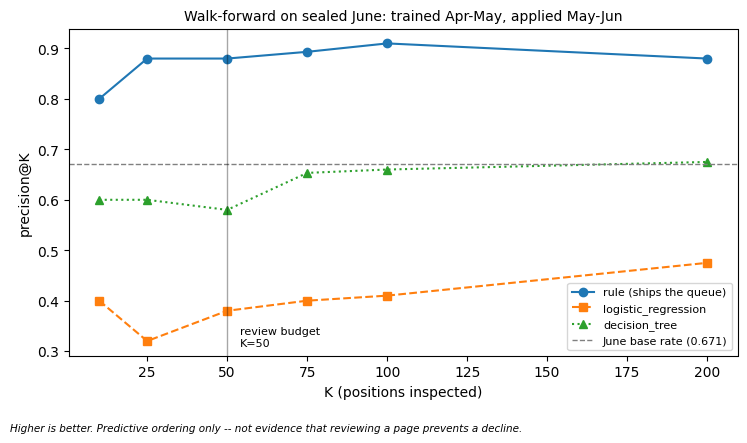

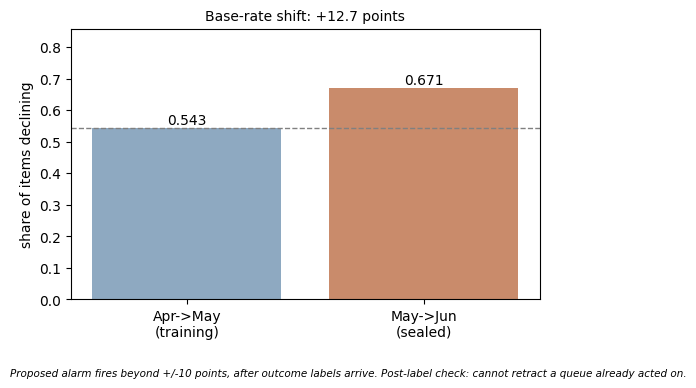

Wrote work/outputs/w07_action_queue.csv  (55,904 rows x 24 cols)  -- gitignored by design.
Wrote work/outputs/w07_playbook_metrics.json  -- COMMIT this one; the paper's numbers trace back to it.
Wrote work/figures/w07_precision_at_k.png and work/figures/w07_base_rate_shift.png -- commit both.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# ---------- Figure 1: precision@K, three orderings vs the base rate ----------
fig, ax = plt.subplots(figsize=(7.5, 4.2))
styles = {"rule (ships the queue)": ("-", "o"), "logistic_regression": ("--", "s"), "decision_tree": (":", "^")}
for name in orderings:
    ls, mk = styles[name]
    ax.plot(KS, pk[name].values, linestyle=ls, marker=mk, label=name)
ax.axhline(june_base, color="grey", linestyle="--", linewidth=1, label=f"June base rate ({june_base:.3f})")
ax.axvline(REVIEW_BUDGET, color="black", linewidth=1, alpha=0.35)
ax.annotate(f"review budget\nK={REVIEW_BUDGET}", xy=(REVIEW_BUDGET, ax.get_ylim()[0]),
            xytext=(REVIEW_BUDGET + 4, ax.get_ylim()[0] + 0.02), fontsize=8, color="black")
ax.set_xlabel("K (positions inspected)")
ax.set_ylabel("precision@K")
ax.set_title("Walk-forward on sealed June: trained Apr-May, applied May-Jun", fontsize=10)
ax.legend(fontsize=8)
fig.text(0.01, -0.04, "Higher is better. Predictive ordering only -- not evidence that reviewing a page "
                       "prevents a decline.", fontsize=7.5, style="italic")
plt.tight_layout()
plt.savefig("work/figures/w07_precision_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Figure 2: base-rate shift, the monitoring story ----------
fig, ax = plt.subplots(figsize=(5.5, 3.6))
bars = ax.bar(["Apr->May\n(training)", "May->Jun\n(sealed)"], [train_base, june_base],
              color=["#8ea9c1", "#c98b6b"])
ax.axhline(train_base, color="grey", linestyle="--", linewidth=1)
for b, v in zip(bars, [train_base, june_base]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylabel("share of items declining")
ax.set_ylim(0, max(train_base, june_base) * 1.28)
ax.set_title(f"Base-rate shift: {shift_pts:+.1f} points", fontsize=10)
fig.text(0.01, -0.06, "Proposed alarm fires beyond +/-10 points, after outcome labels arrive. "
                       "Post-label check: cannot retract a queue already acted on.", fontsize=7.5, style="italic")
plt.tight_layout()
plt.savefig("work/figures/w07_base_rate_shift.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- The queue CSV (regenerated, never committed) ----------
export_cols = ["queue_rank", "action", "content_hash_id", "client_hash_id",
               "rule_reason", "lr_reason", "tree_reason", "agreement", "tree_path",
               "rule_score", "rule_ranked", "lr_decline_probability", "tree_predicts_decline",
               "position_tier", "prev_30_avg_position", "prev_30_impressions", "prev_30_clicks",
               "prev_30_ctr", "expected_ctr_for_tier", "ctr_gap", "eligible",
               "content_age_days_at_decision", "days_since_last_update_at_decision",
               "is_declining_june"]
queue_path = "work/outputs/w07_action_queue.csv"
queue[export_cols].to_csv(queue_path, index=False)
print(f"Wrote {queue_path}  ({len(queue):,} rows x {len(export_cols)} cols)  -- gitignored by design.")

# ---------- The receipts ----------
metrics = {
    "notebook": "w07_action_playbook.ipynb",
    "warehouse_build": "flyrank_pseudonymized_warehouse_release_v20260703",
    "training_frame": {"as_of": "2026-05-31", "decision_moment": "2026-05-01",
                        "n_rows": int(len(X_train)), "n_clients": int(meta_train["client_hash_id"].nunique()),
                        "base_rate": train_base},
    "sealed_june_frame": {"as_of": "2026-07-01", "decision_moment": "2026-06-01",
                           "n_rows": int(len(queue)), "n_clients": int(queue["client_hash_id"].nunique()),
                           "base_rate": june_base, "read": "once"},
    "queue": {"ordered_by": "rule score (impressions x ctr_gap)",
               "reason_codes": ["rule_reason", "lr_reason", "tree_reason", "tree_path", "agreement"],
               "review_budget": REVIEW_BUDGET,
               "n_rule_flagged": int(queue["rule_ranked"].sum()),
               "n_eligible": int(queue["eligible"].sum()),
               "agreement_mix": {k: int(v) for k, v in queue["agreement"].value_counts().items()}},
    "walk_forward_precision_at_k": {name: {str(k): float(v) for k, v in zip(KS, pk[name].values)} for name in orderings},
    "june_classification_metrics": june_metrics.to_dict(orient="index"),
    "monitoring": {"base_rate_shift_points": float(shift_pts),
                    "base_rate_alarm_threshold_points": 10,
                    "base_rate_alarm_would_fire": bool(abs(shift_pts) > 10),
                    "psi_threshold": 0.25,
                    "n_features_over_psi_threshold": n_sig,
                    "top_psi": {k: float(v) for k, v in psi_scores.head(5).items()},
                    "status": "proposed policy, not an implemented system"},
    "claims": {"causal": "none -- no controlled comparison exists",
                "scope": "one walk-forward month; ordering is decision-support, not a recovery claim"},
}
metrics_path = "work/outputs/w07_playbook_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Wrote {metrics_path}  -- COMMIT this one; the paper's numbers trace back to it.")
print("Wrote work/figures/w07_precision_at_k.png and work/figures/w07_base_rate_shift.png -- commit both.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.